In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer 
from sklearn.preprocessing import StandardScaler , OneHotEncoder , QuantileTransformer
from sklearn.metrics import root_mean_squared_error , r2_score , mean_squared_error
from sklearn.model_selection import train_test_split



In [148]:
df = pd.read_csv("CBB.csv")

In [104]:
# df.head()
# df.info()
# df.describe()
# df.shape
df.columns


Index(['ID', 'Age', 'Income', 'Education', 'City', 'YearsExperience',
       'CreditScore', 'OnlineVisits', 'AnnualSpend'],
      dtype='object')

In [107]:
df.isna().sum().sort_values(ascending=False)

ID                 0
Age                0
Income             0
Education          0
City               0
YearsExperience    0
CreditScore        0
OnlineVisits       0
AnnualSpend        0
dtype: int64

In [134]:

num_col = df.select_dtypes(include=['int64','float64']).columns
imputer = IterativeImputer(max_iter=5,random_state=42) 
df[num_col]= imputer.fit_transform(df[num_col])



In [108]:
df.head()

,ID,Age,Income,Education,City,YearsExperience,CreditScore,OnlineVisits,AnnualSpend
0,1.0,22.0,36000.0,High School,New York,0.0,650.0,6.0,2300.0
1,2.0,23.0,38000.0,High School,Houston,1.0,655.0,7.0,2450.0
2,3.0,24.0,39000.0,High School,Houston,1.0,660.0,8.0,2600.0
3,4.0,25.0,42000.0,Bachelors,New York,2.0,690.0,12.0,3200.0
4,5.0,26.0,43000.0,Bachelors,Houston,2.0,685.0,11.0,3300.0


In [ ]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
iqr = q3-q1
lower_bound= q1 - 1.5*iqr
upper_bound= q3 + 1.5*iqr

df = df[(df['Age']>=lower_bound) & (df['Age']<=upper_bound)]

q1 = df['OnlineVisits'].quantile(0.25)
q3 = df['OnlineVisits'].quantile(0.75)
iqr1 = q3-q1
lower_bound= q1 - 1.5*iqr
upper_bound= q3 + 1.5*iqr

df = df[(df['OnlineVisits']>=lower_bound) & (df['OnlineVisits']<=upper_bound)]

<Axes: xlabel='Age'>

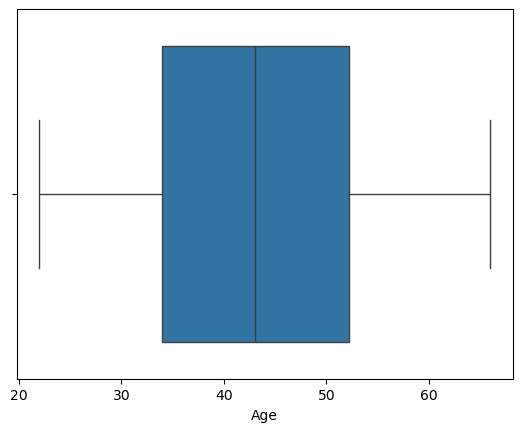

In [114]:
# sns.boxplot(x=df['Age'])
sns.boxplot(x=df['Age'])

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[num_col])

In [116]:
df.columns

Index(['ID', 'Age', 'Income', 'Education', 'City', 'YearsExperience',
       'CreditScore', 'OnlineVisits', 'AnnualSpend'],
      dtype='object')

<Axes: xlabel='CreditScore', ylabel='Count'>

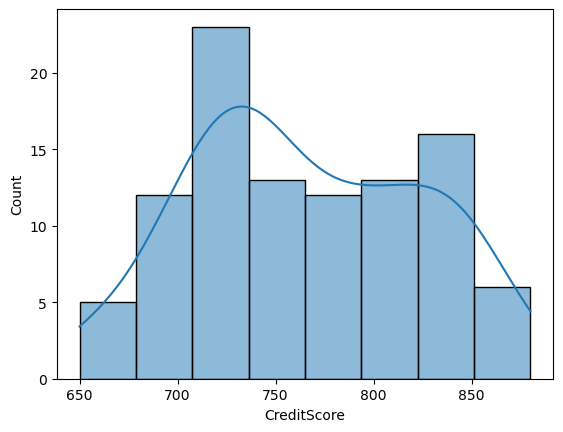

In [125]:
sns.histplot(x=df['CreditScore'] , kde=True)

In [126]:
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df['CreditScore']= qt.fit_transform(df[['CreditScore']])

c:\adeelrana\envs\ml_algo\lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (100). n_quantiles is set to n_samples.
  warnings.warn(


<Axes: xlabel='CreditScore', ylabel='Count'>

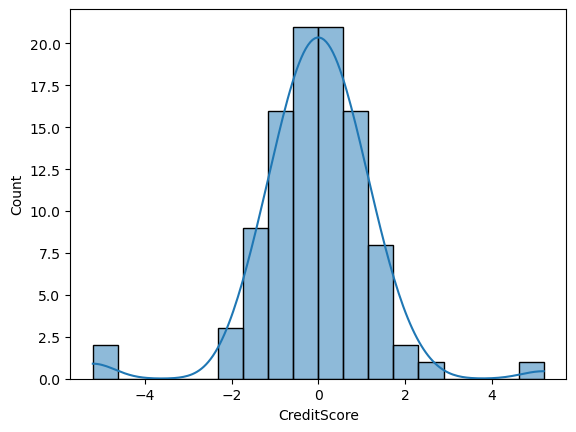

In [127]:
sns.histplot(x=df['CreditScore'] , kde=True)

In [137]:
X = df[['Age','Income','CreditScore']]
y= df[['AnnualSpend']]
model = LinearRegression()
model.fit(X,y)
model.predict([[23,25000,700]])


c:\adeelrana\envs\ml_algo\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[837.00651432]])

In [138]:
df.head()

,ID,Age,Income,Education,City,YearsExperience,CreditScore,OnlineVisits,AnnualSpend
0,1.0,22.0,36000.0,High School,New York,0.0,650.0,6.0,2300.0
1,2.0,23.0,38000.0,High School,Houston,1.0,655.0,7.0,2450.0
2,3.0,24.0,39000.0,High School,Houston,1.0,660.0,8.0,2600.0
3,4.0,25.0,42000.0,Bachelors,New York,2.0,690.0,12.0,3200.0
4,5.0,26.0,43000.0,Bachelors,Houston,2.0,685.0,11.0,3300.0


In [144]:
# df = df.drop('Education',axis=1)
df = df.drop('City',axis=1)
df.head()

,ID,Age,Income,YearsExperience,CreditScore,OnlineVisits,AnnualSpend
0,1.0,22.0,36000.0,0.0,650.0,6.0,2300.0
1,2.0,23.0,38000.0,1.0,655.0,7.0,2450.0
2,3.0,24.0,39000.0,1.0,660.0,8.0,2600.0
3,4.0,25.0,42000.0,2.0,690.0,12.0,3200.0
4,5.0,26.0,43000.0,2.0,685.0,11.0,3300.0


In [145]:
X = df.drop('AnnualSpend' , axis=1)
y = df['AnnualSpend']


X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
y_pred= model.predict(X_test)

In [147]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(f"RMSE:{rmse}")

r2 = r2_score(y_test,y_pred)
print(f"r2 Score : {r2}")



RMSE:267.98270909747447
r2 Score : 0.9939079595815716


In [149]:
df.head()

,ID,Age,Income,Education,City,YearsExperience,CreditScore,OnlineVisits,AnnualSpend
0,1,22,36000.0,High School,New York,0.0,650.0,6,2300
1,2,23,38000.0,High School,Houston,1.0,655.0,7,2450
2,3,24,39000.0,High School,Houston,1.0,660.0,8,2600
3,4,25,42000.0,Bachelors,New York,2.0,690.0,12,3200
4,5,26,43000.0,Bachelors,Houston,2.0,685.0,11,3300


In [150]:
df.columns

Index(['ID', 'Age', 'Income', 'Education', 'City', 'YearsExperience',
       'CreditScore', 'OnlineVisits', 'AnnualSpend'],
      dtype='object')

In [152]:
X = df.drop('AnnualSpend' , axis=1)
y= df['AnnualSpend']

cat_col = ['Education','City']

encoder = OneHotEncoder(drop="first",sparse_output=False)
encoded_array = encoder.fit_transform(X[cat_col])

encoded_df = pd.DataFrame(encoded_array,columns=encoder.get_feature_names_out(cat_col),index=X.index)

X_numeric = X.drop(cat_col,axis=1)
x_final = pd.concat([X_numeric,encoded_df],axis=1)


In [153]:
x_final

,ID,Age,Income,YearsExperience,CreditScore,OnlineVisits,Education_High School,Education_Masters,Education_PhD,City_Houston,City_Los Angeles,City_New York,City_San Francisco
0,1,22,36000.0,0.0,650.0,6,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,23,38000.0,1.0,655.0,7,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,24,39000.0,1.0,660.0,8,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,25,42000.0,2.0,690.0,12,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,26,43000.0,2.0,685.0,11,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,46,79000.0,21.0,770.0,26,0.0,1.0,0.0,0.0,0.0,0.0,0.0
96,97,50,88000.0,25.0,800.0,29,0.0,0.0,1.0,0.0,0.0,0.0,1.0
97,98,54,92000.0,30.0,820.0,31,0.0,0.0,1.0,0.0,0.0,0.0,1.0
98,99,58,98000.0,35.0,830.0,33,0.0,0.0,1.0,0.0,0.0,0.0,1.0
